# O1 fixed-depth rankings by benchmark landscape

This notebook ranks every fixed random-forest depth from 4 through 20 separately for benchmark seeds 40–46. The primary metric is **mean final best regret across the ten SMAC seeds**; lower is better. It also reports mean best regret across the entire 1,000-trial trajectory, which rewards policies that improve earlier.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import t

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)

RELATIVE_EXPERIMENT = Path('experiments/synthaticBench/o1_deterministic/depth_policies/09_big_experiment')
EXPERIMENT = RELATIVE_EXPERIMENT if RELATIVE_EXPERIMENT.exists() else Path.cwd()
FIXED_OUTPUT = EXPERIMENT / 'smac_output' / 'fixed'
BENCHMARK_SEEDS = tuple(range(40, 47))
SMAC_SEEDS = tuple(range(10))
FIXED_DEPTHS = tuple(range(4, 21))
N_TRIALS = 1000
CHECKPOINT_TRIALS = tuple(range(200, N_TRIALS + 1, 200))
EXPECTED_RUNS = len(BENCHMARK_SEEDS) * len(SMAC_SEEDS) * len(FIXED_DEPTHS)
print('Fixed-depth output:', FIXED_OUTPUT.resolve())

Fixed-depth output: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/depth_policies/09_big_experiment/smac_output/fixed


## Load and validate all fixed-depth trajectories

In [2]:
rows = []
missing = []
for benchmark_seed in BENCHMARK_SEEDS:
    for depth in FIXED_DEPTHS:
        for smac_seed in SMAC_SEEDS:
            path = (FIXED_OUTPUT / f'benchmark_seed_{benchmark_seed}' /
                    f'fixed_depth_{depth}' / str(smac_seed) / 'trajectory.json')
            if not path.exists():
                missing.append((benchmark_seed, depth, smac_seed))
                continue
            with path.open() as handle:
                data = json.load(handle)
            best_regret = np.asarray(data.get('best_regret', []), dtype=float)
            errors = []
            if data.get('benchmark_seed') != benchmark_seed:
                errors.append('benchmark_seed')
            if data.get('smac_seed') != smac_seed:
                errors.append('smac_seed')
            if data.get('policy_spec', {}).get('fixed_depth') != depth:
                errors.append('fixed_depth')
            if data.get('n_trials') != N_TRIALS or len(best_regret) != N_TRIALS:
                errors.append('n_trials')
            if errors:
                raise ValueError(f'{path}: invalid {errors}')
            rows.append({
                'benchmark_seed': benchmark_seed,
                'depth': depth,
                'smac_seed': smac_seed,
                'final_best_regret': float(best_regret[-1]),
                'trajectory_mean_best_regret': float(best_regret.mean()),
                'log_trajectory_auc': float(np.log10(np.maximum(best_regret, 1e-300)).mean()),
                **{f'best_regret_at_{trial}': float(best_regret[trial - 1])
                   for trial in CHECKPOINT_TRIALS},
            })

runs = pd.DataFrame(rows)
coverage = pd.DataFrame({
    'found': [len(runs)], 'expected': [EXPECTED_RUNS], 'missing': [len(missing)]
})
display(coverage)
assert not missing, f'Missing fixed-depth trajectories: {missing[:20]}'
assert runs.groupby(['benchmark_seed', 'depth']).size().eq(len(SMAC_SEEDS)).all()
print(f'Validated {len(runs):,} trajectories.')

,found,expected,missing
0,1190,1190,0


Validated 1,190 trajectories.


## Rank by mean incumbent regret every 200 iterations

At each checkpoint, this takes the incumbent (`best_regret`) after exactly 200, 400, 600, 800, or 1,000 completed trials, averages it across the ten SMAC seeds, and ranks the 17 fixed depths separately within each benchmark landscape. Rank 1 is best (lowest regret).

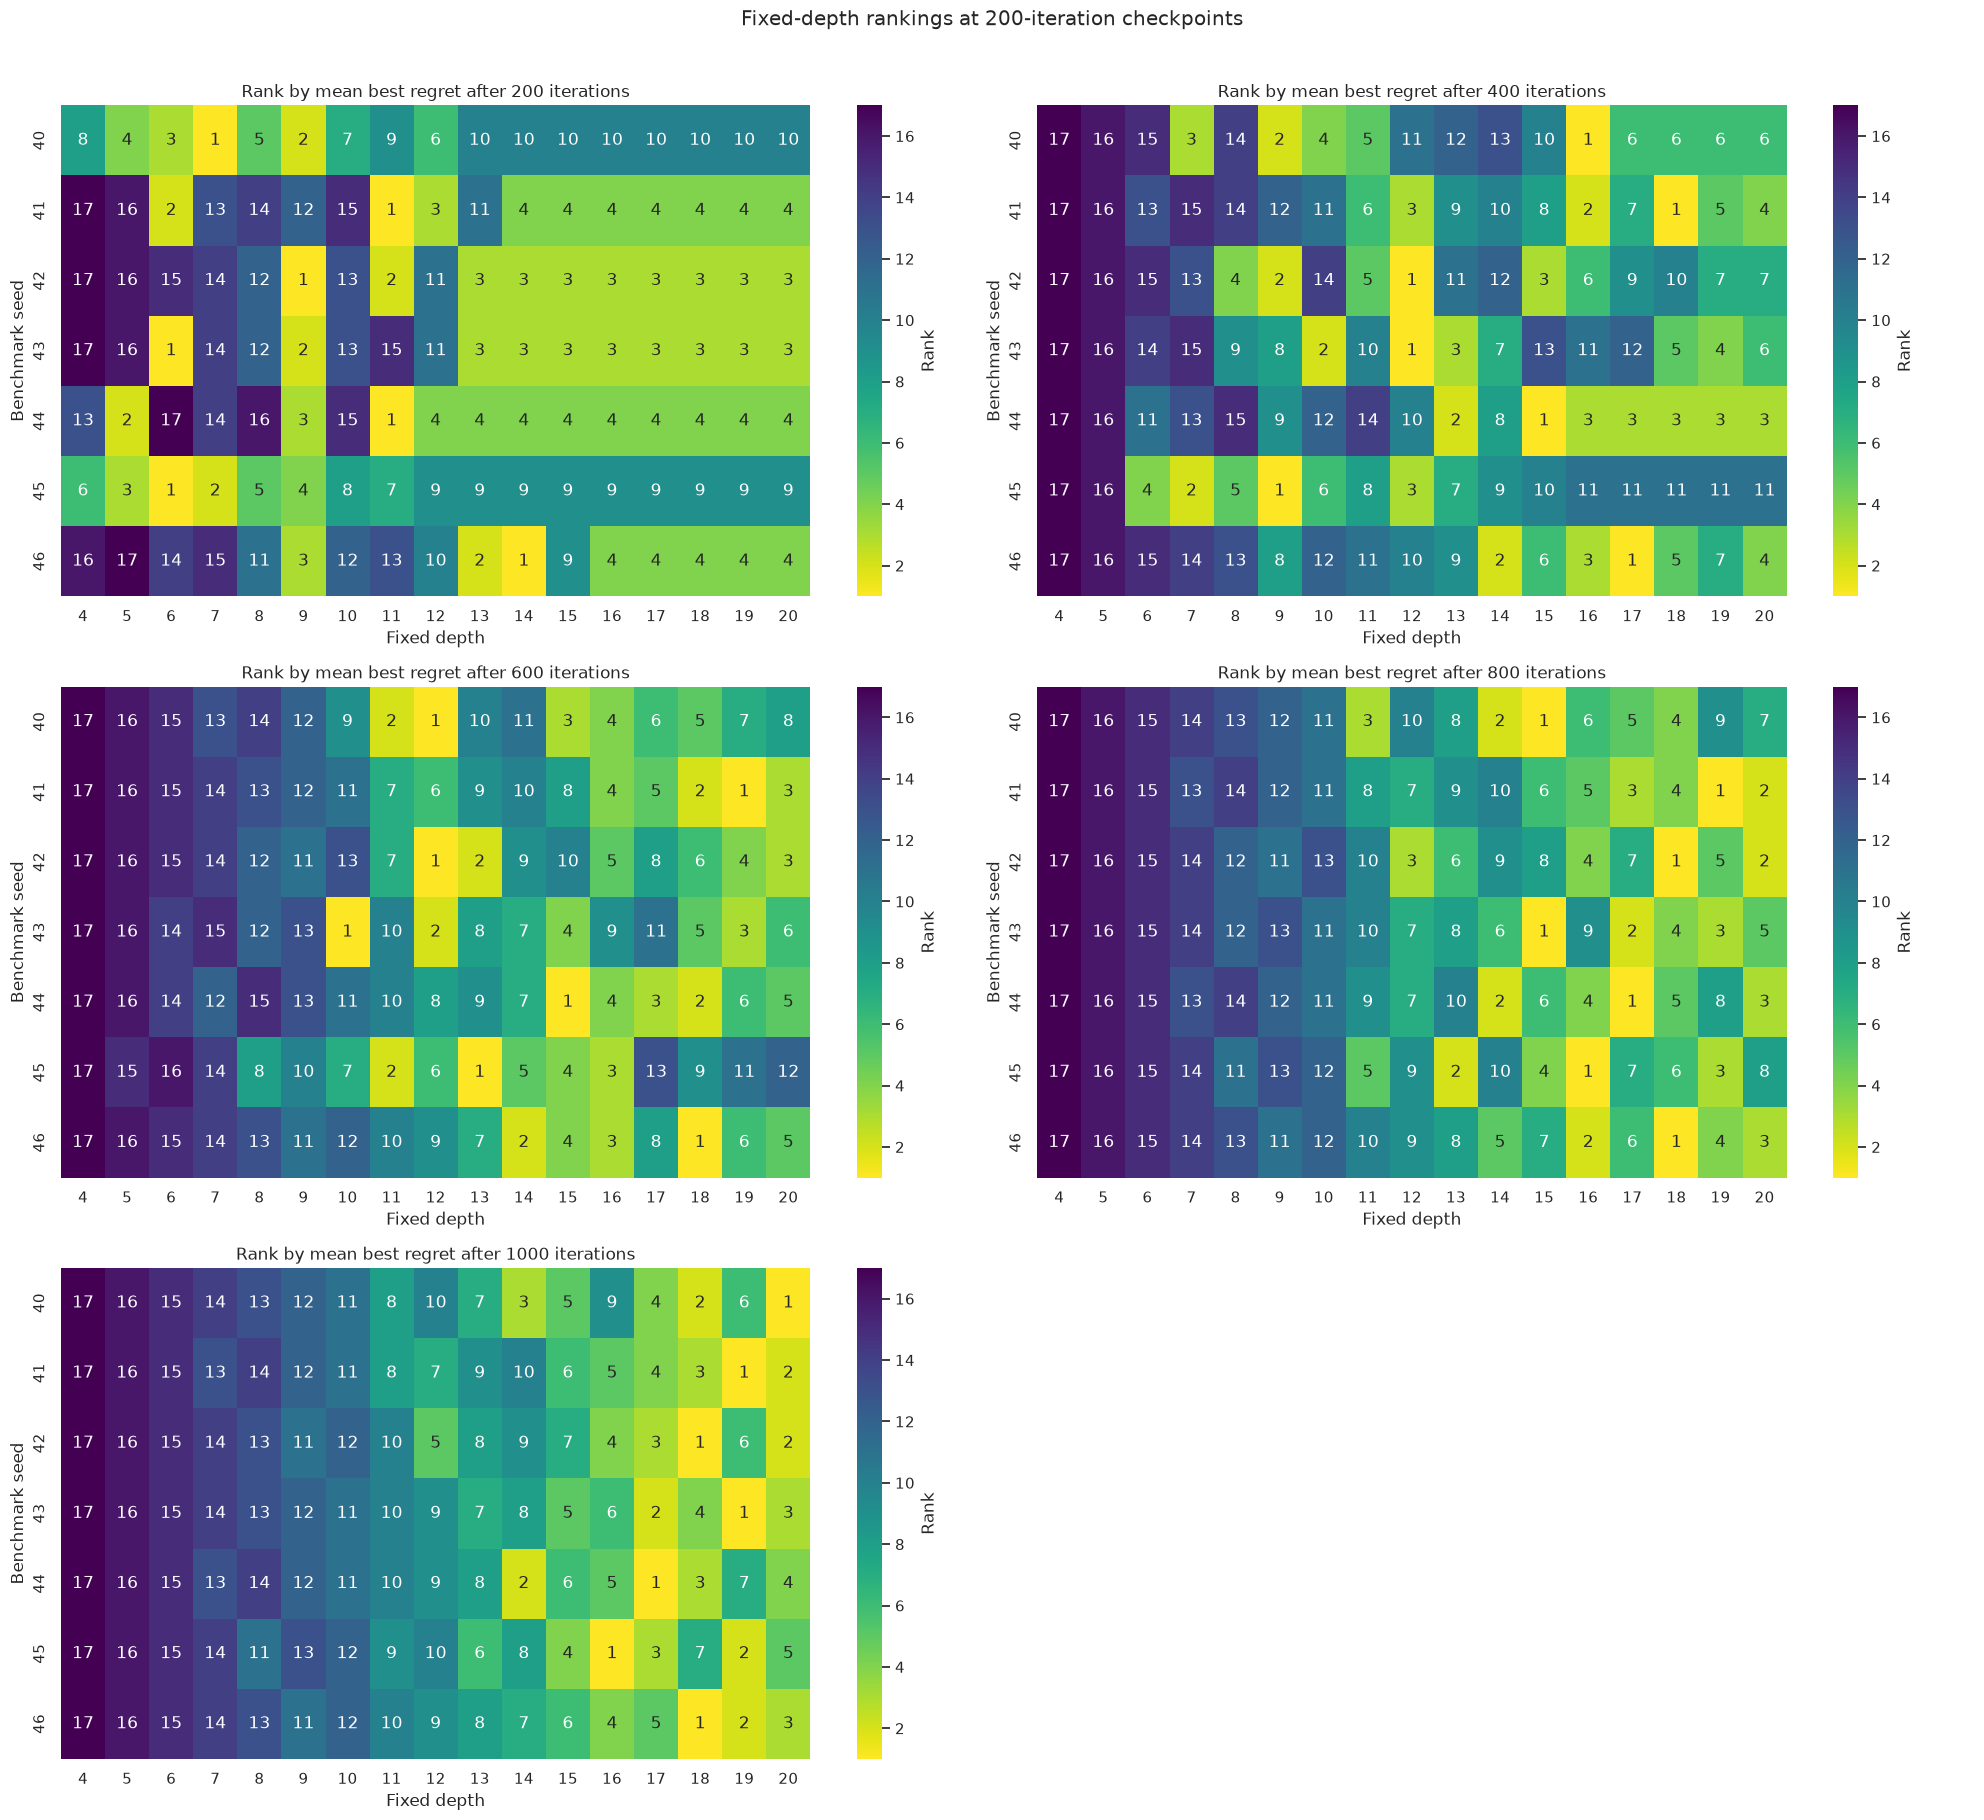

In [3]:
checkpoint_rankings = pd.concat([
    (runs.groupby(['benchmark_seed', 'depth'], as_index=False)
     .agg(mean_best_regret=(f'best_regret_at_{trial}', 'mean'))
     .assign(trial=trial))
    for trial in CHECKPOINT_TRIALS
], ignore_index=True)
checkpoint_rankings['rank'] = (
    checkpoint_rankings.groupby(['trial', 'benchmark_seed'])['mean_best_regret']
    .rank(method='min', ascending=True).astype(int)
)

fig, axes = plt.subplots(3, 2, figsize=(20, 18))
axes = axes.ravel()
for axis, trial in zip(axes, CHECKPOINT_TRIALS):
    rank_matrix = (
        checkpoint_rankings.query('trial == @trial')
        .pivot(index='benchmark_seed', columns='depth', values='rank')
        .reindex(index=BENCHMARK_SEEDS, columns=FIXED_DEPTHS)
    )
    sns.heatmap(
        rank_matrix, annot=True, fmt='.0f', cmap='viridis_r',
        vmin=1, vmax=len(FIXED_DEPTHS), ax=axis,
        cbar_kws={'label': 'Rank'},
    )
    axis.set_title(f'Rank by mean best regret after {trial} iterations')
    axis.set_xlabel('Fixed depth')
    axis.set_ylabel('Benchmark seed')
axes[-1].axis('off')
fig.suptitle('Fixed-depth rankings at 200-iteration checkpoints', y=1.01)
fig.tight_layout()
plt.show()

## Rankings by mean final best regret

For each landscape, the ten SMAC-seed final regrets are averaged for every depth. Rank 1 is the lowest mean regret. The confidence interval describes variation across the ten SMAC seeds within that landscape.

In [4]:
ranking = (
    runs.groupby(['benchmark_seed', 'depth'], as_index=False)
    .agg(
        mean_final_regret=('final_best_regret', 'mean'),
        median_final_regret=('final_best_regret', 'median'),
        std_final_regret=('final_best_regret', 'std'),
        mean_trajectory_regret=('trajectory_mean_best_regret', 'mean'),
        std_trajectory_regret=('trajectory_mean_best_regret', 'std'),
        mean_log_auc=('log_trajectory_auc', 'mean'),
        n=('smac_seed', 'size'),
    )
)
ranking['final_ci95'] = (
    t.ppf(0.975, ranking['n'] - 1) * ranking['std_final_regret'] / np.sqrt(ranking['n'])
)
ranking['final_regret_rank'] = (
    ranking.groupby('benchmark_seed')['mean_final_regret']
    .rank(method='min', ascending=True).astype(int)
)
ranking['trajectory_regret_rank'] = (
    ranking.groupby('benchmark_seed')['mean_trajectory_regret']
    .rank(method='min', ascending=True).astype(int)
)
ranking = ranking.sort_values(['benchmark_seed', 'final_regret_rank', 'depth'])
assert ranking.groupby('benchmark_seed').size().eq(len(FIXED_DEPTHS)).all()

for benchmark_seed in BENCHMARK_SEEDS:
    print(f'Benchmark seed {benchmark_seed}')
    display(
        ranking.query('benchmark_seed == @benchmark_seed')[
            ['final_regret_rank', 'depth', 'mean_final_regret', 'final_ci95',
             'median_final_regret', 'mean_trajectory_regret', 'trajectory_regret_rank']
        ].style.format({
            'mean_final_regret': '{:.6g}',
            'final_ci95': '{:.4g}',
            'median_final_regret': '{:.6g}',
            'mean_trajectory_regret': '{:.6g}',
        })
    )

Benchmark seed 40


,final_regret_rank,depth,mean_final_regret,final_ci95,median_final_regret,mean_trajectory_regret,trajectory_regret_rank
16,1,20,4138.23,854.2,4159.2,31048.7,6
14,2,18,4304.2,1253,4308.52,31023.1,4
10,3,14,4889.01,1790,4491.47,31244.2,8
13,4,17,4992.25,910.4,4612.5,30950.9,3
11,5,15,5036.36,1096,4293.32,30874.6,1
15,6,19,5040.44,1641,4673.23,31151.1,7
9,7,13,5200.55,756.3,5447.67,31446.7,10
7,8,11,5722.29,1536,5317.3,31316.7,9
12,9,16,5774.15,1118,5758.8,30912.7,2
8,10,12,6460.99,2226,5825.2,31043.6,5


Benchmark seed 41


,final_regret_rank,depth,mean_final_regret,final_ci95,median_final_regret,mean_trajectory_regret,trajectory_regret_rank
32,1,19,2220.71,801.9,1984.83,8907.77,1
33,2,20,2511.88,856.7,2261.17,9268.72,3
31,3,18,2701.08,708.1,2207.28,9062.66,2
30,4,17,2772.1,910.1,2790.22,9327.82,5
29,5,16,3002.71,1144,3069.58,9292.95,4
28,6,15,3606.45,1186,3480.09,9895.18,8
25,7,12,4455.31,1336,4324.87,9745.62,7
24,8,11,5030.23,1623,4458.65,9694.36,6
26,9,13,5144.04,1391,5097.01,10691.4,9
27,10,14,5261.59,1539,4455.23,10869.5,10


Benchmark seed 42


...

,final_regret_rank,depth,mean_final_regret,final_ci95,median_final_regret,mean_trajectory_regret,trajectory_regret_rank
81,1,17,6309.9,1537,6276.14,46759.6,1
78,2,14,6666.77,1936,6923.14,46838.2,3
82,3,18,6972.02,2380,6683.29,46987.5,4
84,4,20,7055.65,1804,6062.47,47058.2,5
80,5,16,7065.83,1569,6725.51,47123.1,6
79,6,15,7694.8,1174,7404.13,46765.6,2
83,7,19,7698.49,1734,7954.55,47289.9,7
77,8,13,8391.93,2151,6940.81,48256.7,8
76,9,12,8869.41,1812,8484.31,48378.4,9
75,10,11,9356.33,2633,8124.67,49031.6,10


Benchmark seed 45


,final_regret_rank,depth,mean_final_regret,final_ci95,median_final_regret,mean_trajectory_regret,trajectory_regret_rank
97,1,16,4171.57,1061,4453.34,29860,5
100,2,19,4240.15,1215,4044.17,30285.6,8
98,3,17,4451.48,1449,4851.62,30501.1,10
96,4,15,4602.63,1270,4379.64,30222.7,7
101,5,20,4757.43,1412,5465.88,30540.2,12
94,6,13,4806.64,509.4,4666.78,29590,2
99,7,18,5428.4,2085,5622.2,30505.7,11
95,8,14,5835.77,1536,5811.76,30362.5,9
92,9,11,5931.89,1993,5032.44,29733.1,4
93,10,12,6601.6,1667,6624.69,29724.5,3


Benchmark seed 46


,final_regret_rank,depth,mean_final_regret,final_ci95,median_final_regret,mean_trajectory_regret,trajectory_regret_rank
116,1,18,1877.29,740.6,1640.36,6474.42,1
117,2,19,2322.25,994.5,1779.22,6841.85,5
118,3,20,2664.17,1225,1848.25,6831.91,4
114,4,16,2695.57,864.6,2695.29,6733.63,3
115,5,17,2915.47,1162,2359.28,7022,7
113,6,15,3015.68,943.2,2875.27,6868.29,6
112,7,14,3076.16,604.5,2992.71,6682.35,2
111,8,13,3746.38,1122,3515.94,7394.85,8
110,9,12,4519.53,1538,4624.4,7881.86,9
109,10,11,4597.07,2626,3375.08,8413.37,11


## Rank and average-regret matrices

Rows are benchmark landscapes and columns are fixed depths.

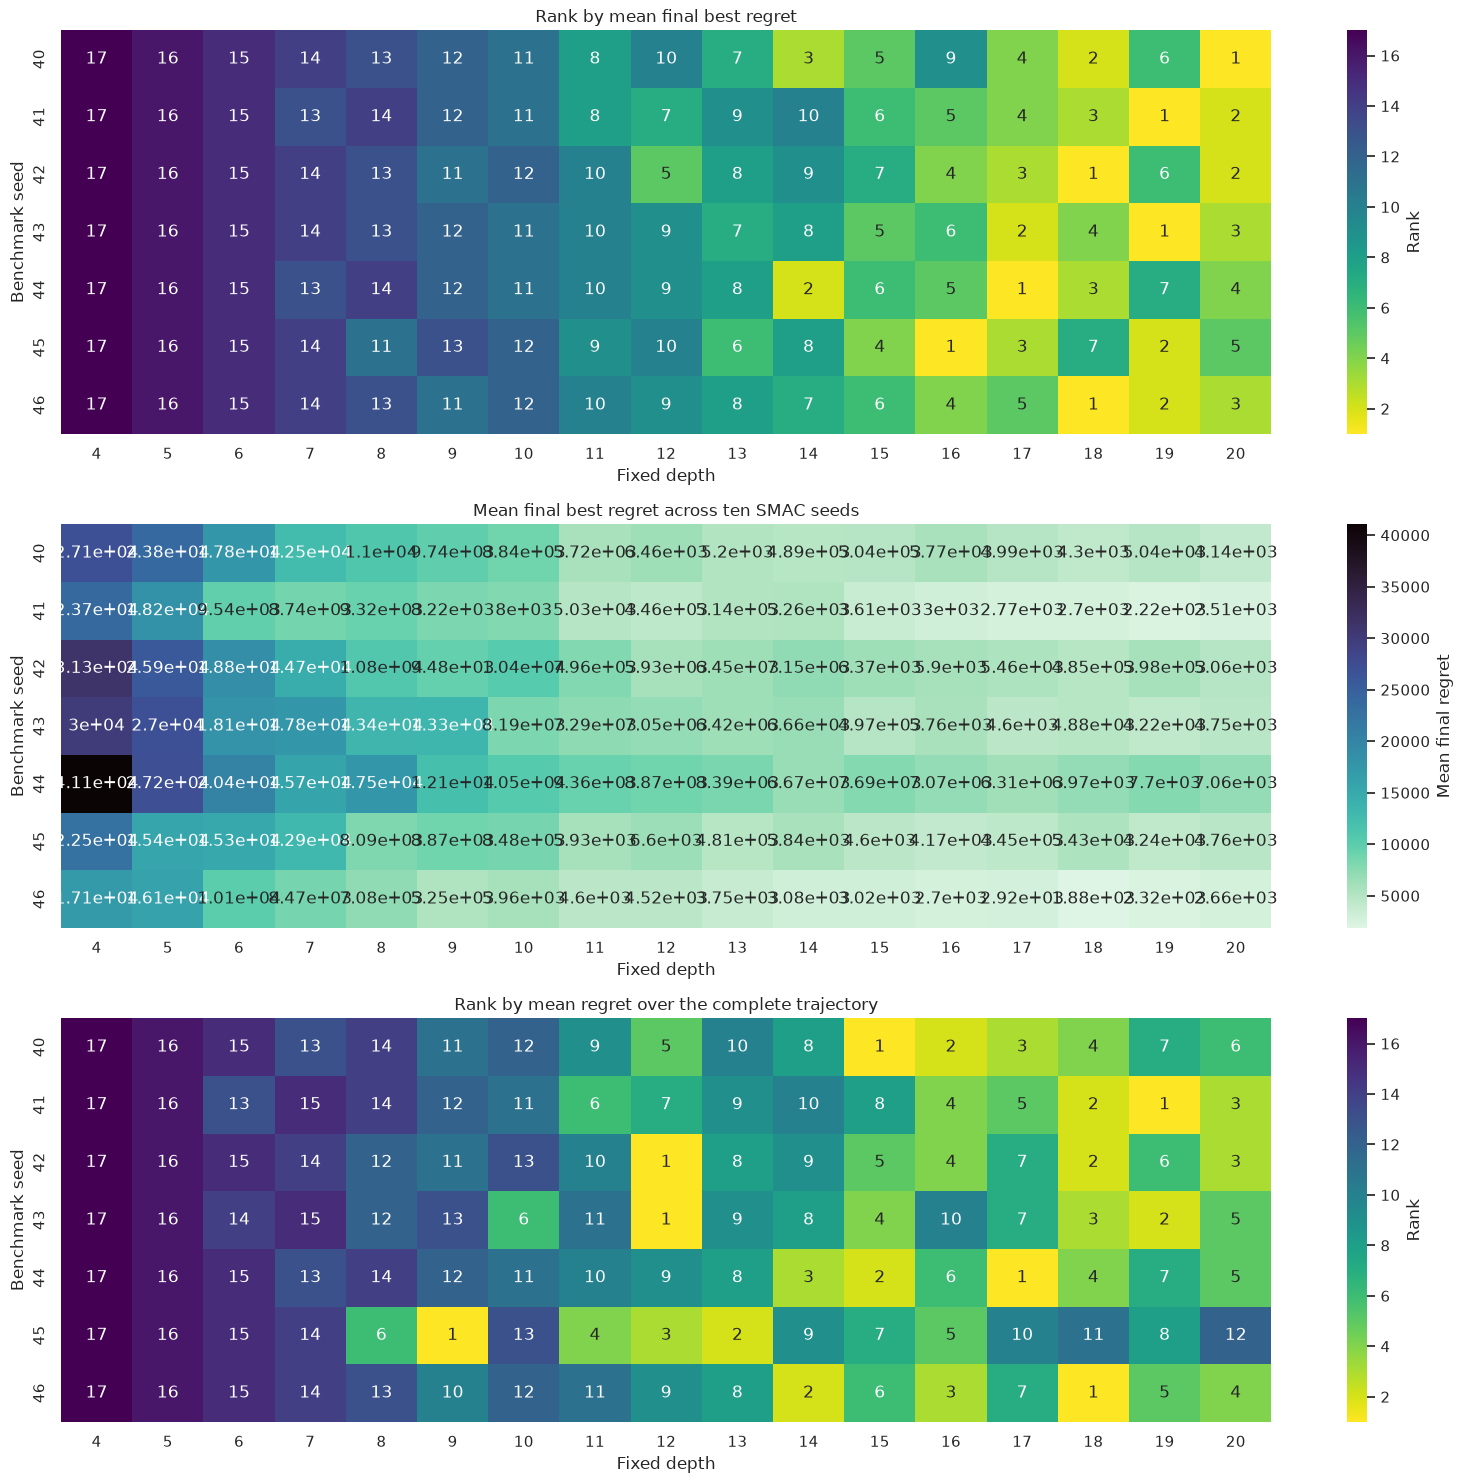

In [5]:
final_rank_matrix = ranking.pivot(index='benchmark_seed', columns='depth', values='final_regret_rank').reindex(index=BENCHMARK_SEEDS, columns=FIXED_DEPTHS)
final_regret_matrix = ranking.pivot(index='benchmark_seed', columns='depth', values='mean_final_regret').reindex(index=BENCHMARK_SEEDS, columns=FIXED_DEPTHS)
trajectory_rank_matrix = ranking.pivot(index='benchmark_seed', columns='depth', values='trajectory_regret_rank').reindex(index=BENCHMARK_SEEDS, columns=FIXED_DEPTHS)

fig, axes = plt.subplots(3, 1, figsize=(16, 15))
sns.heatmap(final_rank_matrix, annot=True, fmt='.0f', cmap='viridis_r', vmin=1, vmax=len(FIXED_DEPTHS), ax=axes[0], cbar_kws={'label': 'Rank'})
axes[0].set_title('Rank by mean final best regret')
sns.heatmap(final_regret_matrix, annot=True, fmt='.3g', cmap='mako_r', ax=axes[1], cbar_kws={'label': 'Mean final regret'})
axes[1].set_title('Mean final best regret across ten SMAC seeds')
sns.heatmap(trajectory_rank_matrix, annot=True, fmt='.0f', cmap='viridis_r', vmin=1, vmax=len(FIXED_DEPTHS), ax=axes[2], cbar_kws={'label': 'Rank'})
axes[2].set_title('Rank by mean regret over the complete trajectory')
for axis in axes:
    axis.set_xlabel('Fixed depth')
    axis.set_ylabel('Benchmark seed')
fig.tight_layout()
plt.show()

## Mean final regret and 95% confidence intervals by landscape

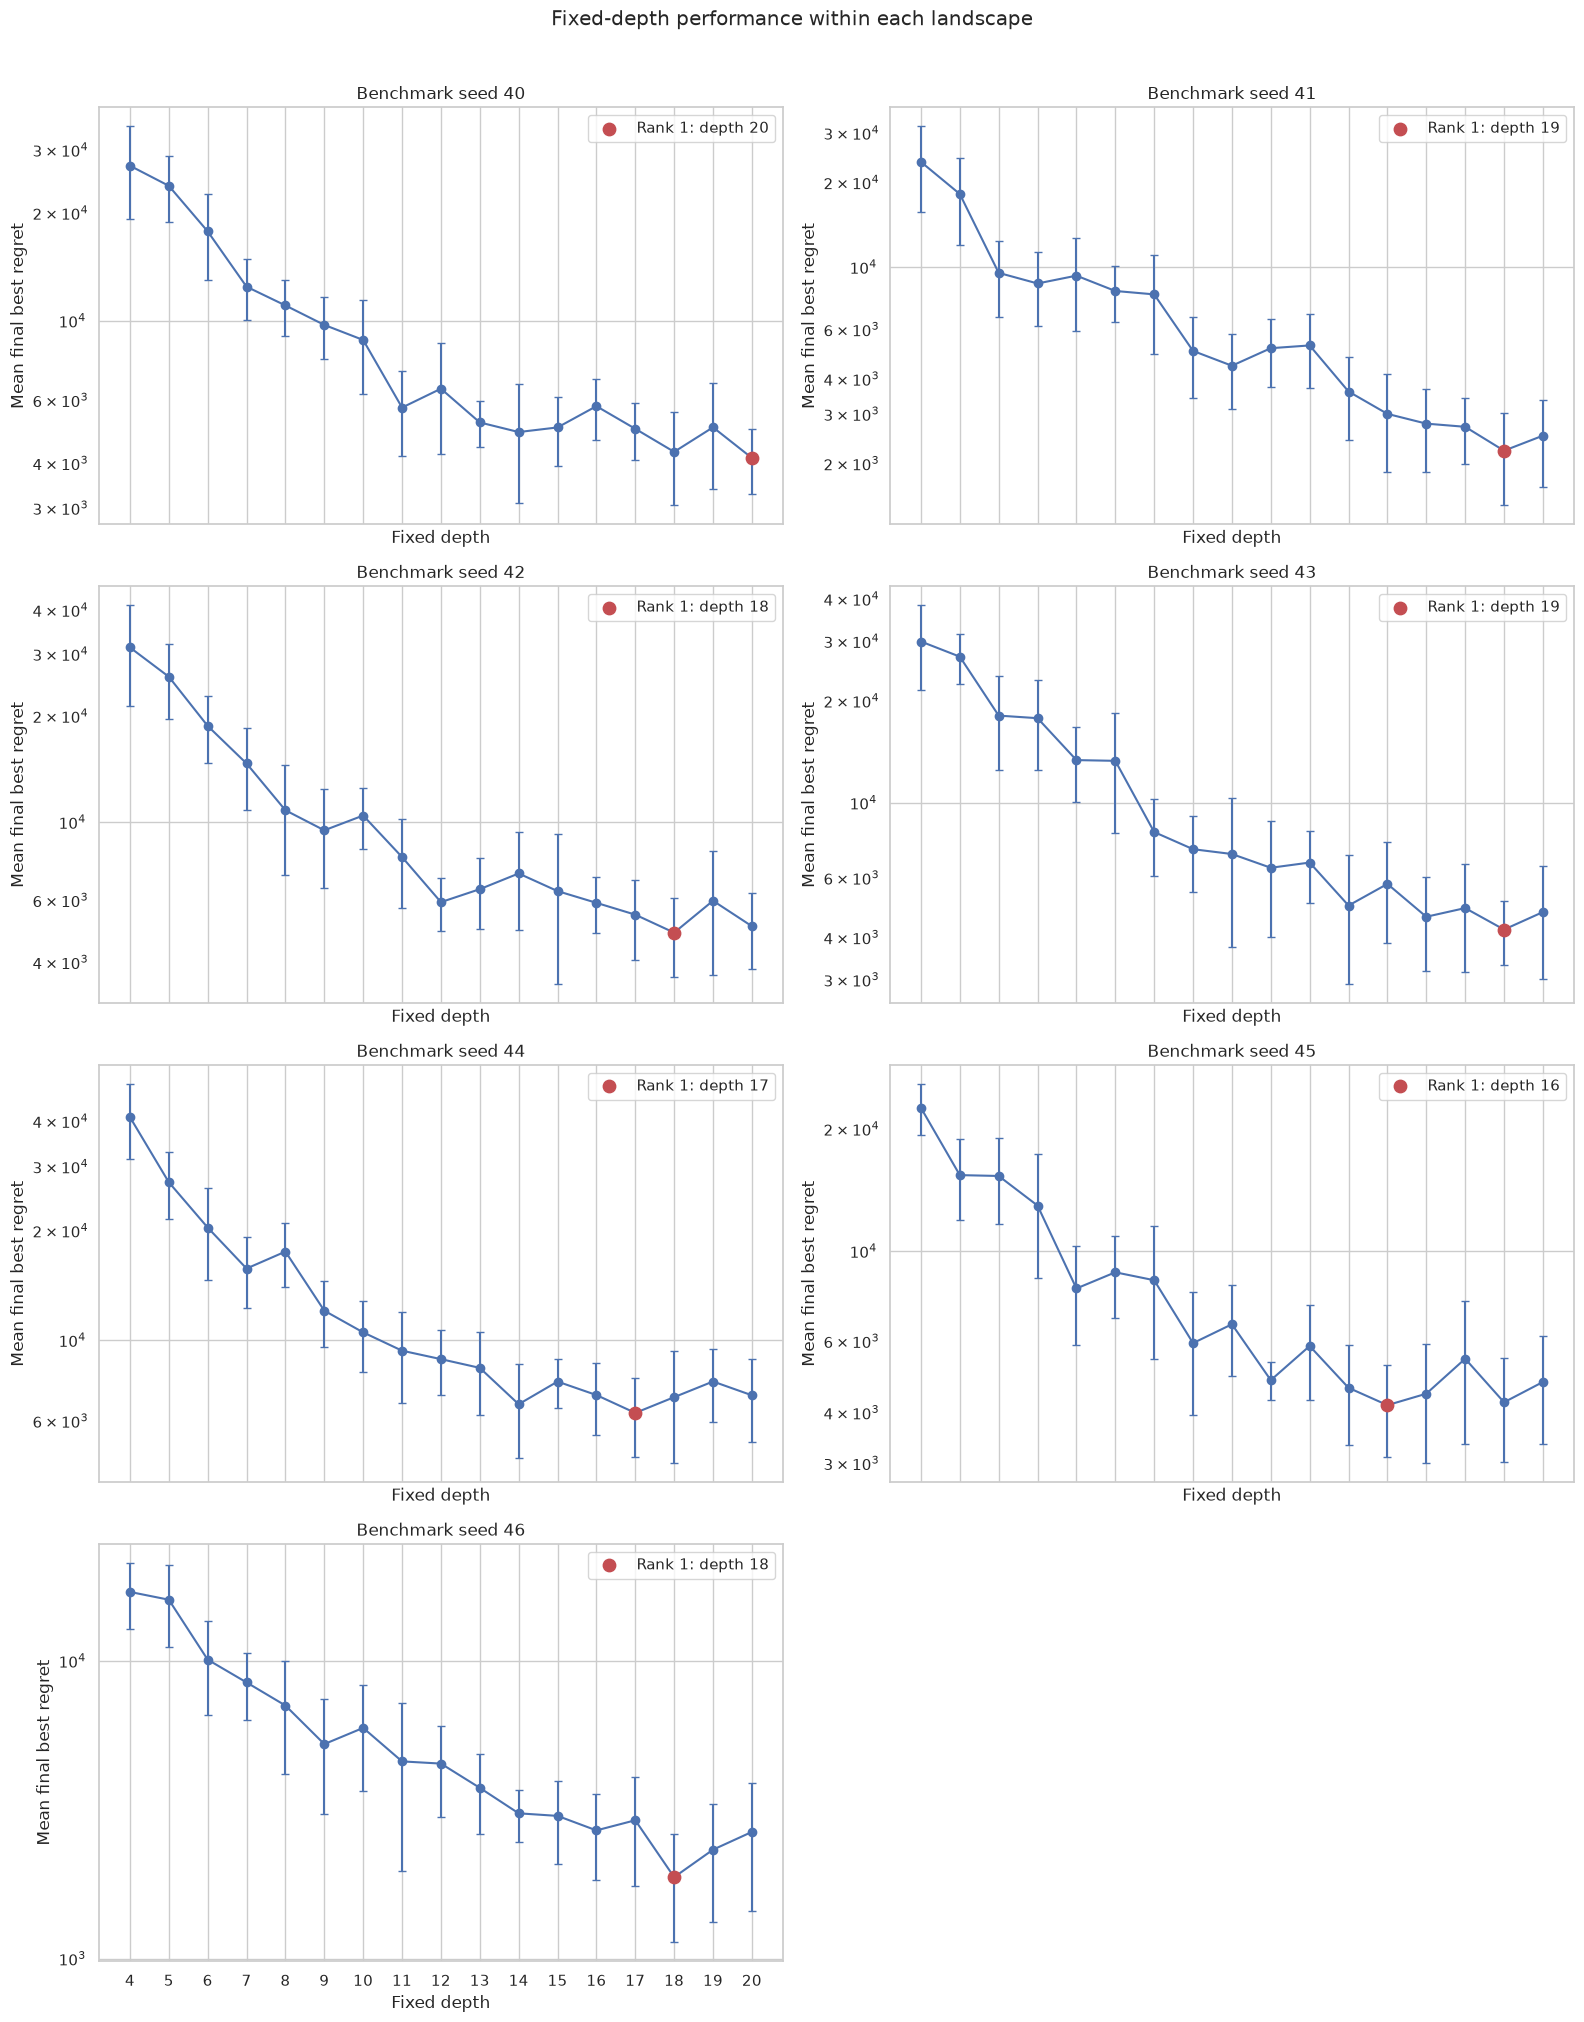

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20), sharex=True)
axes = axes.ravel()
for axis, benchmark_seed in zip(axes, BENCHMARK_SEEDS):
    subset = ranking.query('benchmark_seed == @benchmark_seed').sort_values('depth')
    axis.errorbar(
        subset['depth'], subset['mean_final_regret'], yerr=subset['final_ci95'],
        marker='o', capsize=3, color='C0',
    )
    best = subset.nsmallest(1, 'mean_final_regret').iloc[0]
    axis.scatter([best.depth], [best.mean_final_regret], color='C3', s=80, zorder=3,
                 label=f'Rank 1: depth {int(best.depth)}')
    if subset.mean_final_regret.min() > 0:
        axis.set_yscale('log')
    axis.set_title(f'Benchmark seed {benchmark_seed}')
    axis.set_xlabel('Fixed depth')
    axis.set_ylabel('Mean final best regret')
    axis.set_xticks(FIXED_DEPTHS)
    axis.legend()
axes[-1].axis('off')
fig.suptitle('Fixed-depth performance within each landscape', y=1.01)
fig.tight_layout()
plt.show()

## Cross-landscape rank stability

This final table summarizes ranks across the seven landscapes. It does not replace the per-landscape rankings above.

In [7]:
overall = (
    ranking.groupby('depth', as_index=False)
    .agg(
        mean_final_rank=('final_regret_rank', 'mean'),
        median_final_rank=('final_regret_rank', 'median'),
        best_landscape_rank=('final_regret_rank', 'min'),
        worst_landscape_rank=('final_regret_rank', 'max'),
        rank_1_count=('final_regret_rank', lambda values: int((values == 1).sum())),
        mean_trajectory_rank=('trajectory_regret_rank', 'mean'),
    )
    .sort_values(['mean_final_rank', 'depth'])
)
overall.insert(0, 'cross_landscape_order', np.arange(1, len(overall) + 1))
display(overall.style.format({
    'mean_final_rank': '{:.2f}',
    'median_final_rank': '{:.1f}',
    'mean_trajectory_rank': '{:.2f}',
}))

,cross_landscape_order,depth,mean_final_rank,median_final_rank,best_landscape_rank,worst_landscape_rank,rank_1_count,mean_trajectory_rank
16,1,20,2.86,3.0,1,5,1,5.43
14,2,18,3.00,3.0,1,7,2,3.86
13,3,17,3.14,3.0,1,5,1,5.71
15,4,19,3.57,2.0,1,7,2,5.14
12,5,16,4.86,5.0,1,9,1,4.86
11,6,15,5.57,6.0,4,7,0,4.71
10,7,14,6.71,8.0,2,10,0,7.00
9,8,13,7.57,8.0,6,9,0,7.71
8,9,12,8.43,9.0,5,10,0,5.00
7,10,11,9.29,10.0,8,10,0,8.71
